# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

In [62]:
import matplotlib.pyplot as plt
import plotly_express as px
import seaborn as sns
import pandas as pd
import numpy as np
import category_encoders as ce
from category_encoders import JamesSteinEncoder
from pandas import DataFrame
from sklearn.compose import make_column_selector as selector



### Read the vechicles.csv

In [63]:
vehicles = pd.read_csv('data/vehicles.csv')
vehicles.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [64]:
# Display the first few rows of the dataset
vehicles.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [65]:
# Display the few last rows of the dataset
vehicles.tail() 

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
426875,7301591192,wyoming,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,1N4AA6AV6KC367801,fwd,NaN,sedan,NaN,wy
426876,7301591187,wyoming,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,gas,12029.0,clean,other,7JR102FKXLG042696,fwd,NaN,sedan,red,wy
426877,7301591147,wyoming,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,diesel,4174.0,clean,other,1GYFZFR46LF088296,NaN,NaN,hatchback,white,wy
426878,7301591140,wyoming,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,58ABK1GG4JU103853,fwd,NaN,sedan,silver,wy
426879,7301591129,wyoming,30590,2019.0,bmw,4 series 430i gran coupe,good,NaN,gas,22716.0,clean,other,WBA4J1C58KBM14708,rwd,NaN,coupe,NaN,wy


### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

### Steps to understand the Data
- Get information about the dataframe
- Identify columns with missing values
- Identify the categorical columns 


In [66]:
all_columns = list(vehicles.columns)
# Identify columns with missing values
missing_values = vehicles[all_columns].isna().sum()/len(vehicles) * 100
print("All Column with % of missing values")
for col in all_columns:
    print(f"- {col}: {missing_values[col]:.2f}% missing values")

All Column with % of missing values
- id: 0.00% missing values
- region: 0.00% missing values
- price: 0.00% missing values
- year: 0.28% missing values
- manufacturer: 4.13% missing values
- model: 1.24% missing values
- condition: 40.79% missing values
- cylinders: 41.62% missing values
- fuel: 0.71% missing values
- odometer: 1.03% missing values
- title_status: 1.93% missing values
- transmission: 0.60% missing values
- VIN: 37.73% missing values
- drive: 30.59% missing values
- size: 71.77% missing values
- type: 21.75% missing values
- paint_color: 30.50% missing values
- state: 0.00% missing values


In [67]:
# Identify Categorical columns
from sklearn.compose import make_column_selector as selector
categorical_columns_selector = selector(dtype_include=object)
categorical_columns = categorical_columns_selector(vehicles)
categorical_columns
# Indentify missing values for categorical columns
missing_values = vehicles[categorical_columns].isna().sum()/len(vehicles) * 100
print("Categorical Column with % of missing values")
for col in categorical_columns:
    print(f"- {col}: {missing_values[col]:.2f}% missing values")

Categorical Column with % of missing values
- region: 0.00% missing values
- manufacturer: 4.13% missing values
- model: 1.24% missing values
- condition: 40.79% missing values
- cylinders: 41.62% missing values
- fuel: 0.71% missing values
- title_status: 1.93% missing values
- transmission: 0.60% missing values
- VIN: 37.73% missing values
- drive: 30.59% missing values
- size: 71.77% missing values
- type: 21.75% missing values
- paint_color: 30.50% missing values
- state: 0.00% missing values


### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

# Data Prparation
- Remove columns that are not required
    - Drop columns with high missing values (missing values more than 30%)

    - Drop id, paid_color these will not be a contribution feature
    - Year
        - Convert fillna for year with min(year)
        - Convert year to int (drop the decimal values)
    - Drop the rows with high impact features with low% of missing values 
        - Price
            - Drop the rows with price is 0 or NaN/Null
        - Manufacturer
            - Drop the rows with manufacturer is NaN
- Limiting the scope of analysis to:
    - Model = ['sedan', 'SUV', 'pickup', 'truck', 'coupe', 'hatchback', 'van', 'wagon', 'convertible', 'minivan']
    - title_status = ['clean']
- Remove duplicate rows
- Removing outliers Rows
    - where price is > 300_000 (300K)
    - odometer reading is > 300_000 (300K)
- Convert the datatype of columns if required
- populate missing values, if there are any for categorical columns
- convert the categorical columns to number using category encoding Remove the 


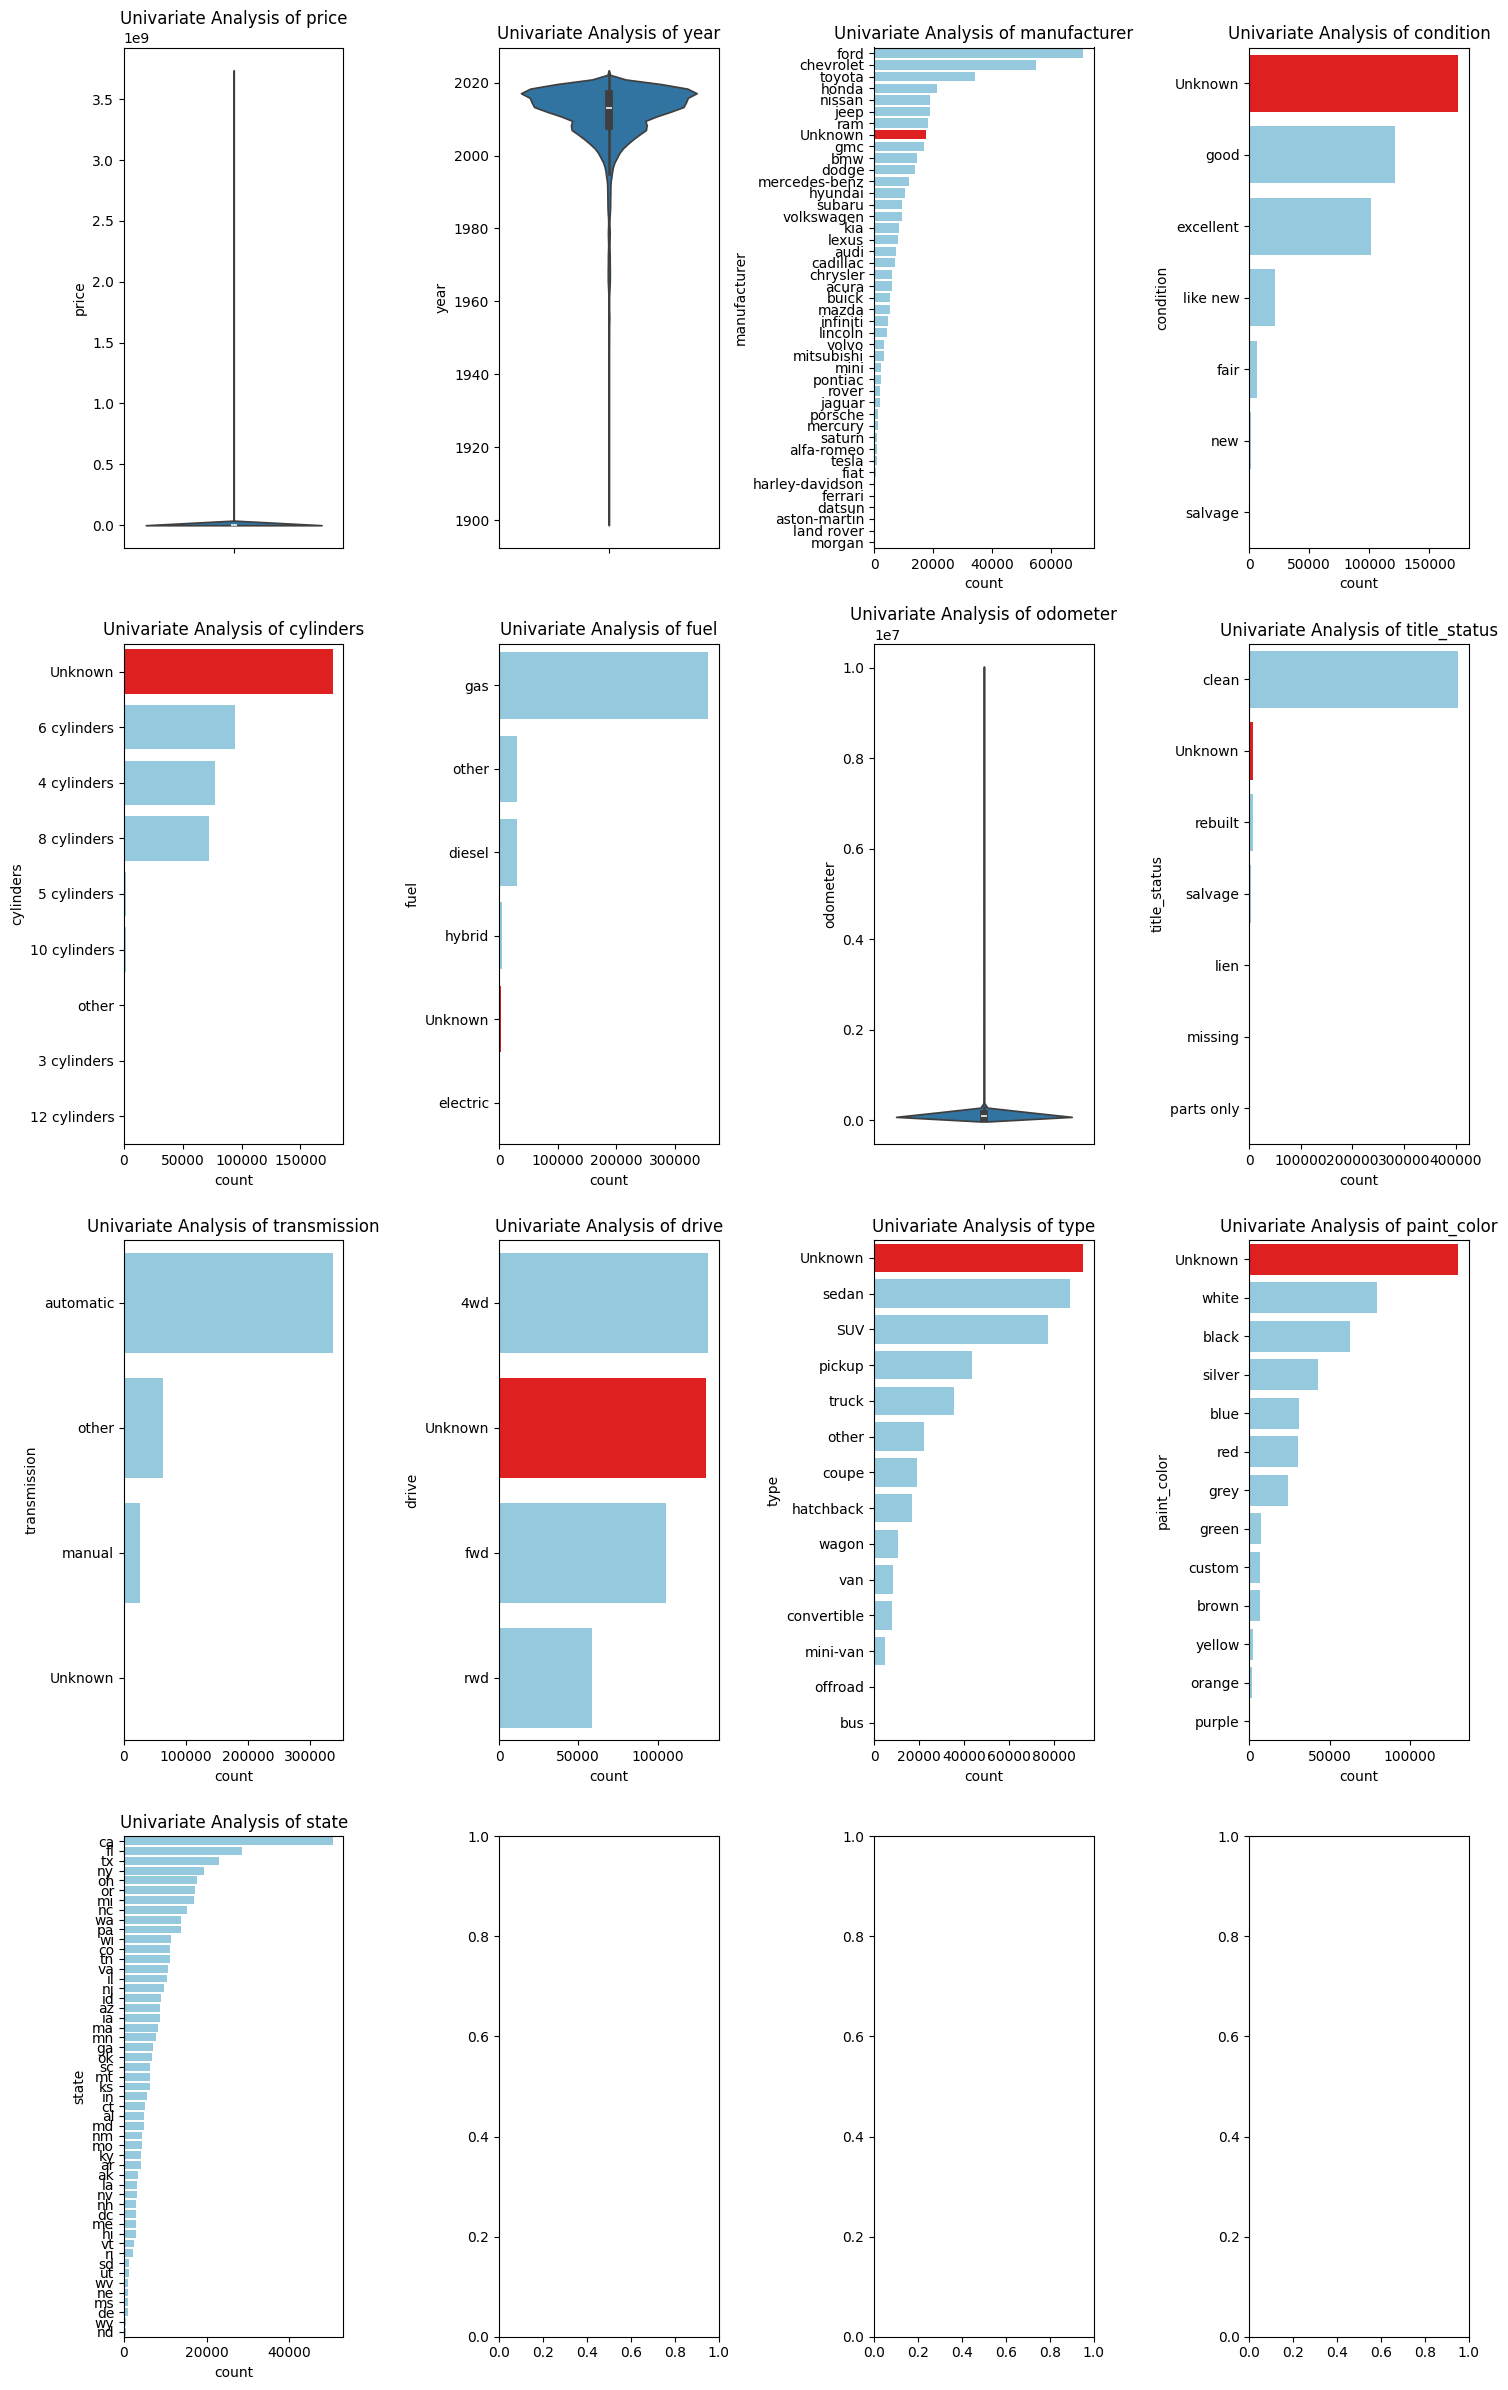

In [68]:
# Generate graphical representation of missing values
# Create function to plot univariate analysis
def plot_univariate_analysis(df:DataFrame, column:str, ax, i:int):
    if df[column].dtype == 'object':
        # Countplot for categorical variables with missing value called as 'missing'
        data = df[column].fillna('Unknown').to_frame()
        # Create a new pallette where color for missing value is different from other columns
        palette = {val: ("red" if val == 'Unknown' else "skyblue") for val in data[column].unique()}
        # Countplot for categorical variables
        sns.countplot(data=data, 
                      y=column, 
                      hue=column, 
                      ax=ax[i],
                      order=data[column].value_counts().index, palette=palette, legend=False)
        axes[i].set_title(f'Univariate Analysis of {column}') 
    else:
        # Countplot for Numerical variables with missing value called as -999
        data = df[column].fillna(np.median(df[column])).to_frame()
        sns.violinplot(data=data, y=column, ax=ax[i])
        ax[i].set_title(f'Univariate Analysis of {column}')


# Create the following univariate plots as subplots in a 3x2 grid
fig, axes = plt.subplots(4, 4, figsize=(15, 24))
# Flatten the axes array for easy iteration
axes = axes.flatten()

# We will not generate univariate for feature that have large number of distinct values
# Loop through each column and create univariate plots
columns = list(vehicles.columns)
remove_columns = ['id','region', 'model', 'VIN', 'size']
# Remove columns that are not needed for univariate analysis
for col in remove_columns:
    if col in columns:
        columns.remove(col)

for i, column in enumerate(columns):
        plot_univariate_analysis(vehicles, column,axes,i)
plt.tight_layout()
plt.savefig('images/univariate_analysis.png', dpi=300, bbox_inches='tight')
plt.show()


In [69]:
# Based on the univariate analysis, we will limit the dataset to the following values of model and title_status
vechicle_model_scope = ['sedan', 'SUV', 'pickup', 'truck', 'coupe', 'hatchback', 'van', 'wagon', 'convertible', 'minivan']
title_scope = ['clean']
# Filter the dataset for the model scope
selected_df = vehicles.query('type in @vechicle_model_scope and title_status in @title_scope')
# Remove outliers in the price and odometer columns
selected_df = selected_df.query('price < 300_000 and odometer < 300_000')
# remove duplicates
selected_df = selected_df.drop_duplicates()
# Identify columns to drop where missing values are greater than 30%
columns_to_drop = []
for col in categorical_columns:
    if missing_values[col] > 30:
        columns_to_drop.append(col)
# Drop columns with high missing values
# Adding id column to the list of columns to drop
columns_to_drop.append('id')
print("\nColumn dropped due to high %of missing values:")
for col in columns_to_drop:
    print(f"- {col}")
selected_df = selected_df.drop(columns=columns_to_drop)
# Drop the rows where price is missing or zero
selected_df = selected_df[selected_df['price'] > 0]
# Drop the rows where manufacturer is missing 
selected_df = selected_df.dropna(subset=['manufacturer'])



Column dropped due to high %of missing values:
- condition
- cylinders
- VIN
- drive
- size
- paint_color
- id


In [70]:
selected_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 255237 entries, 27 to 426879
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        255237 non-null  object 
 1   price         255237 non-null  int64  
 2   year          255233 non-null  float64
 3   manufacturer  255237 non-null  object 
 4   model         253404 non-null  object 
 5   fuel          254021 non-null  object 
 6   odometer      255237 non-null  float64
 7   title_status  255237 non-null  object 
 8   transmission  254168 non-null  object 
 9   type          255237 non-null  object 
 10  state         255237 non-null  object 
dtypes: float64(2), int64(1), object(8)
memory usage: 23.4+ MB


In [71]:
# # Create new column 'year_number' with the year as int
# # Fill missing values for year with the minimum year -1
# # Convert year to int (drop the decimal part)
# df_encoded['year_number'] = df_encoded['year'].fillna(vehicles['year'].min()).astype(int)
# # create new column odometer_encoded by fill missing values with the median
# # Convert odometer to int (drop the decimal part)
# # drop the original columns odometer and year
# df_encoded['odometer_encoded'] = df_encoded['odometer'].fillna(df_encoded['odometer'].median()).astype(int)
# # Encode model, fuel, and title_status and transmission 
# # Populate NaN/Null values with 'unknown'
# df_encoded['model_encoded'] = df_encoded['model'].fillna('unknown')
# df_encoded['fuel_encoded'] = df_encoded['fuel'].fillna('unknown')
# df_encoded['transmission_encoded'] = df_encoded['transmission'].fillna('unknown')
# # Drop original columns model, fuel, and transmission, year and odometer
# df_encoded = df_encoded.drop(columns=['year','odometer', 'model', 'fuel', 'transmission'])


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [72]:
# Encode the categorical columns
columns_to_encode = list(selected_df.columns)
# remove the target column 'price' from the list of columns to encode
columns_to_encode.remove('price')
# Check the number of unique values and missing values for each categorical column
uniq_values  = selected_df[columns_to_encode].nunique()
na_value = selected_df[columns_to_encode].isna().sum()
print("\nUnique values and missing values for categorical columns:")
for col in columns_to_encode:
    print(f"- {col}: {uniq_values[col]} unique values, {na_value[col]} missing values")
# Identify columns with missing values
# Encode the final_columns_to_encode using James-Stein estimator
print("\nFinal columns to encode:")
for col in columns_to_encode:
    print(f"- {col}")



Unique values and missing values for categorical columns:
- region: 404 unique values, 0 missing values
- year: 102 unique values, 4 missing values
- manufacturer: 42 unique values, 0 missing values
- model: 17022 unique values, 1833 missing values
- fuel: 5 unique values, 1216 missing values
- odometer: 75681 unique values, 0 missing values
- title_status: 1 unique values, 0 missing values
- transmission: 3 unique values, 1069 missing values
- type: 9 unique values, 0 missing values
- state: 51 unique values, 0 missing values

Final columns to encode:
- region
- year
- manufacturer
- model
- fuel
- odometer
- title_status
- transmission
- type
- state


In [73]:
encoder = ce.JamesSteinEncoder(cols=columns_to_encode,
                              random_state=42)

In [74]:


def fit_transform(encoder:JamesSteinEncoder, df:DataFrame, target_col:str) -> DataFrame:
    """
    Fit the encoder to the data and transform it.
    """
    # Fit the encoder to the data
    encode_df = encoder.fit_transform(df[columns_to_encode], df[target_col])
    for ec in encode_df.columns:
        df[f"{ec}_encoded"] = encode_df[ec]
    return df


# Split the data into training, testing and validation sets
train_df, test_df, validation_df = np.split(selected_df,[int(0.7 * len(selected_df)), (int(0.7 * len(selected_df))+int(0.2 * len(selected_df)))])
# Fit the encoder to the training set
train_df = fit_transform(encoder, train_df, 'price')
# Transform the test set
test_df = fit_transform(encoder, test_df, 'price')
# Transform the Validation set
validation_df = fit_transform(encoder, validation_df, 'price')


/opt/anaconda3/envs/ber_aiml_py311/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [75]:
# Identify Categorical columns
numerical_feature_selector = selector(dtype_include=np.number)
numerical_features = list(numerical_feature_selector(test_df))
# drop the target column 'price' from the list of columns to encode
numerical_features.remove('price')
numerical_features.remove('year')
numerical_features.remove('odometer')
print("\nNumerical Features:")
for nf in numerical_features:
    print(f"- {nf}")



Numerical Features:
- region_encoded
- year_encoded
- manufacturer_encoded
- model_encoded
- fuel_encoded
- odometer_encoded
- title_status_encoded
- transmission_encoded
- type_encoded
- state_encoded


In [76]:
# Build the model using pipeline 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import SelectKBest, f_regression



In [77]:
def get_MSE_for_degree_k_model(k:int, data:DataFrame, numerical_columns:list[str], target_col:str) -> float:
    pipeline_model = Pipeline([('transform', PolynomialFeatures(degree=k)),
                               ('regression', LinearRegression(fit_intercept=True))])
    # Fit the model to the training data
    pipeline_model.fit(data[numerical_columns], data[target_col])
    # calculate the MSE
    return mean_squared_error(pipeline_model.predict(data[numerical_columns]), data[target_col])

ks = np.array(range(0, 5))
# Create a list of degrees to test
MSEs = []
for k in ks:
    mse_train = get_MSE_for_degree_k_model(k=k,
                                           data=train_df,
                                           numerical_columns=numerical_features, 
                                           target_col='price')
    mse_validate = get_MSE_for_degree_k_model(k=k,
                                            data=validation_df,
                                            numerical_columns=numerical_features, 
                                            target_col='price')
    MSEs.append({'k':k, 'mse_train':mse_train, 'mse_validate':mse_validate})
mse_df = pd.DataFrame(MSEs)
mse_df
model_polynomial_degree = 3
# Polynomial regression model with degree 3 has the lowest MSE

In [78]:


model_selector_pipe = Pipeline([('scaler', StandardScaler()),
                                ('poly_features', PolynomialFeatures(degree = model_polynomial_degree, include_bias = False)),
                                ('feature_selection', SelectKBest(score_func=f_regression, k=5)),
                                ('model', LinearRegression())])
#
model_selector_pipe.fit(train_df[numerical_features], train_df['price'])
selector_train_mse = mean_squared_error(model_selector_pipe.predict(train_df[numerical_features]),train_df['price'])
selector_test_mse = mean_squared_error(model_selector_pipe.predict(test_df[numerical_features]),test_df[['price']])
feature_select = model_selector_pipe.named_steps['feature_selection'].get_support(indices=True)
coefficients = model_selector_pipe.named_steps['model'].coef_
intercept = model_selector_pipe.named_steps['model'].intercept_
print(f"Train MSE: {selector_train_mse}")
print(f"Test MSE: {selector_test_mse}")




Train MSE: 35445982.67432106
Test MSE: 25960611.389685825


Coefficients: [1637.15121959 3869.09741756 9188.69476041 -302.79520324  -22.16422468]
Intercept: 19221.022790912404
Features selected: [  1   3   5 124 262]
Selected feature names: ['year_encoded' 'model_encoded' 'odometer_encoded'
 'year_encoded^2 odometer_encoded' 'odometer_encoded type_encoded^2']


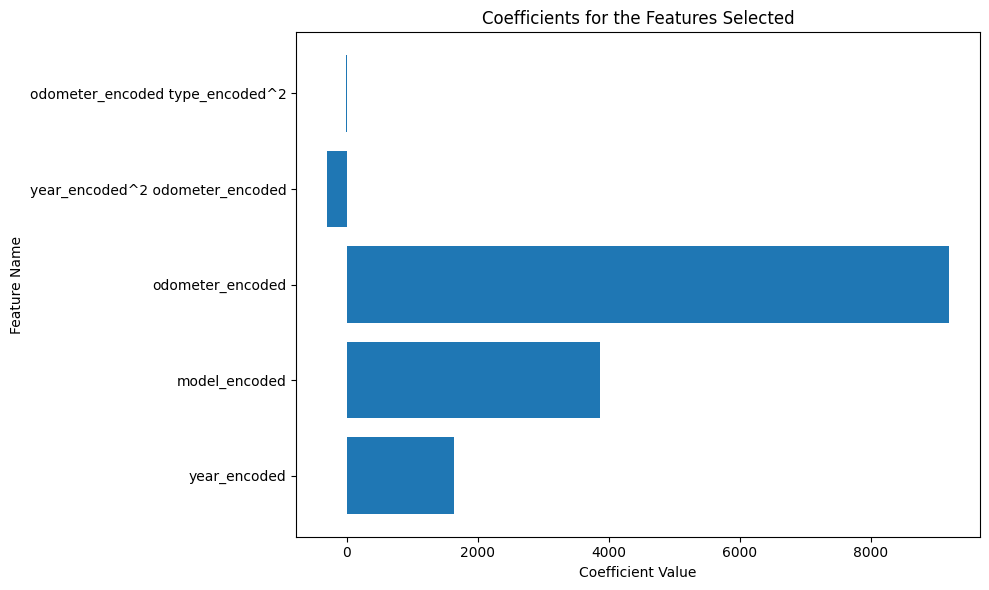

In [79]:
# print information for coefficients, intercept and features selected
print(f"Coefficients: {coefficients}")
print(f"Intercept: {intercept}")
print(f"Features selected: {feature_select}")

# get actual feature names for the features selected
feature_names = model_selector_pipe.named_steps['poly_features'].get_feature_names_out(train_df[numerical_features].columns)
# get the feature names for the features selected
selected_feature_names = feature_names[feature_select]
# # print the feature names for the features selected
print(f"Selected feature names: {selected_feature_names}")
#plot the coefficients for the features selected
plt.figure(figsize=(10, 6))
plt.barh(selected_feature_names, coefficients)
plt.xlabel('Coefficient Value')
plt.ylabel('Feature Name')
plt.title('Coefficients for the Features Selected')
plt.tight_layout()
plt.show()

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.